## 0. Introducción

Este notebook explora `detecciones_crudas`, un dataset sintético que replica el
esquema del componente `lidar_box` del Waymo Open Dataset v2. Cada fila es una
detección: un objeto identificado por el sensor LiDAR de un vehículo autónomo en
un instante determinado. No es un registro de viajes ni de vehículos propios, es
un registro de lo que el vehículo detectó a su alrededor.

El dataset tiene 40.680 filas y 16 columnas, repartidas en 153 segmentos de
conducción de aproximadamente 20 segundos cada uno. El docente inyectó a
propósito cerca de 10 defectos de calidad en los datos, con el objetivo de que
los identifiquemos y decidamos cómo tratarlos. El archivo original en
`data/01_raw/` no se modifica en ningún paso de este trabajo.

Este notebook busca responder tres preguntas:

1. Qué problemas de calidad tiene el dataset y cuántas filas afecta cada uno.
2. Qué relaciones de los datos son reales y hay que conservar, aunque el
   criterio estadístico estándar las marque como atípicas.
3. Qué transformaciones aplicar antes de usar estos datos en un pipeline de
   Kedro.

Las secciones 0 a 7 cubren el diagnóstico. La limpieza y la verificación quedan
para las secciones 8 a 10, en una próxima entrega.

In [1]:
%load_ext kedro.ipython

The kedro.ipython extension is already loaded. To reload it, use:
  %reload_ext kedro.ipython


In [2]:
df = catalog.load("detecciones_crudas")

print(f"Filas: {df.shape[0]:,}  |  Columnas: {df.shape[1]}")
print(f"Memoria: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB\n")
print(df.dtypes)

[09/05/26 18:37:05] INFO     Loading data from detecciones_crudas (CSVDataset)...              ]8;id=4542720;file://C:\Users\maico\waymo-evaluacion\.venv\lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=4542721;file://C:\Users\maico\waymo-evaluacion\.venv\lib\site-packages\kedro\io\data_catalog.py#1050\1050]8;;\

Filas: 40,680  |  Columnas: 16
Memoria: 23.7 MB

segment_id               object
timestamp_micros         object
id_interno               object
object_type              object
box_center_x            float64
box_center_y            float64
box_center_z            float64
box_length              float64
box_width               float64
box_height              float64
speed_mps               float64
num_lidar_points          int64
weather                  object
time_of_day              object
detection_difficulty     object
sensor_version           object
dtype: object


## 1. Carga e inspección

In [3]:
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
print()
print(df.dtypes)

Filas: 40,680
Columnas: 16

segment_id               object
timestamp_micros         object
id_interno               object
object_type              object
box_center_x            float64
box_center_y            float64
box_center_z            float64
box_length              float64
box_width               float64
box_height              float64
speed_mps               float64
num_lidar_points          int64
weather                  object
time_of_day              object
detection_difficulty     object
sensor_version           object
dtype: object


In [4]:
df.head()

,segment_id,timestamp_micros,id_interno,object_type,box_center_x,box_center_y,box_center_z,box_length,box_width,box_height,speed_mps,num_lidar_points,weather,time_of_day,detection_difficulty,sensor_version
0,seg_0063,1692575018900000,det_0026901,VEHICLE,41.004,23.086,1.529,4.414,1.585,1.622,2.214,40,sunny,Day,LEVEL_1,v2.0.1
1,seg_0139,1694475019100000,det_0033893,PEDESTRIAN,48.027,0.412,0.628,0.951,0.664,1.452,1.630,37,sunny,Night,LEVEL_1,v2.0.1
2,seg_0061,1692525000700000,det_0023746,VEHICLE,15.731,-28.511,1.207,13.703,2.830,3.401,8.504,63,sunny,Day,LEVEL_1,v2.0.1
3,seg_0019,1691475019200000,det_0006728,SIGN,21.945,-23.360,0.751,0.446,0.402,2.239,0.000,-1,sunny,Day,LEVEL_1,v2.0.1
4,seg_0047,1692175009900000,det_0036298,VEHICLE,23.309,23.357,0.862,5.159,1.650,1.680,10.501,65,soleado,Day,LEVEL_2,v2.0.1


In [5]:
df.describe()

,box_center_x,box_center_y,box_center_z,box_length,box_width,box_height,speed_mps,num_lidar_points
count,40680.000000,40680.000000,40680.000000,40680.000000,40680.000000,40680.000000,39893.000000,40680.000000
mean,18.083233,-0.007237,0.898605,3.303947,1.455827,1.695893,7.397144,134.809882
std,22.023089,11.960241,0.398113,2.430856,0.623307,0.347135,17.185421,121.155436
min,-72.265000,-46.918000,-0.678000,-13.784000,0.200000,0.000000,0.000000,-1.000000
25%,3.177750,-8.097000,0.633000,0.936000,0.817000,1.519000,1.326000,54.000000
50%,18.203500,-0.094500,0.898000,3.990000,1.725000,1.676000,5.350000,96.000000
75%,32.957000,8.024000,1.167000,4.788000,1.952000,1.819000,10.790000,175.000000
max,107.662000,50.619000,2.769000,17.998000,2.900000,3.598000,338.386000,933.000000


In [6]:
df.describe(include="object")

,segment_id,timestamp_micros,id_interno,object_type,weather,time_of_day,detection_difficulty,sensor_version
count,40680,40680,40680,40680,38605,40680,40680,40680
unique,153,22304,40000,7,11,3,2,1
top,seg_0152,N/D,det_0005031,VEHICLE,sunny,Day,LEVEL_1,v2.0.1
freq,304,60,2,25111,19374,28494,36165,40680


### Hallazgos

- El dataset tiene 40.680 filas y 16 columnas: 8 son de texto, tipo `object`
  (`segment_id`, `timestamp_micros`, `id_interno`, `object_type`, `weather`,
  `time_of_day`, `detection_difficulty`, `sensor_version`) y 8 son numéricas
  (`box_center_x`, `box_center_y`, `box_center_z`, `box_length`, `box_width`,
  `box_height`, `speed_mps`, `num_lidar_points`).
- `timestamp_micros` debería ser numérica y pandas la cargó como texto. Es la
  primera señal de que tiene valores no numéricos mezclados.
- `id_interno` tiene 40.000 valores únicos en 40.680 filas: hay al menos 680
  identificadores repetidos, lo revisamos en la sección 4.
- `num_lidar_points` muestra un mínimo de -1 en el describe numérico. Un conteo
  de puntos no puede ser negativo, lo revisamos en la sección 3.
- `box_length` muestra un mínimo negativo (-13,78) en el describe. Una
  longitud no puede ser negativa, lo revisamos en la sección 5.
- `speed_mps` tiene una desviación estándar (17,19) mayor que su propia media
  (7,40), lo que anticipa valores extremos. Lo revisamos en la sección 5.

In [7]:
# Verificacion 2.3: la introduccion afirma 153 segmentos, lo confirmamos aqui
n_segmentos = df["segment_id"].nunique()
print(f"Segmentos unicos (segment_id): {n_segmentos}")

Segmentos unicos (segment_id): 153


### Hallazgos (verificación adicional)

- `segment_id` tiene 153 valores únicos. Coincide con la cifra afirmada en la
  introducción, no hay que corregir nada ahí.

## 2. Variables categóricas

In [8]:
cat_cols = ["object_type", "weather", "time_of_day", "detection_difficulty", "sensor_version"]
for c in cat_cols:
    print(f"--- {c} ---")
    print(df[c].value_counts(dropna=False))
    print()

--- object_type ---
object_type
VEHICLE       25111
PEDESTRIAN     9134
SIGN           3303
Pedestrian     1069
PEATON          811
CYCLIST         789
Ped             463
Name: count, dtype: int64

--- weather ---
weather
sunny      19374
rain        5761
Sunny       3179
SUNNY       2821
fog         2664
NaN         2075
soleado     1567
RAIN        1186
 rain        836
Fog          476
lluvia       453
niebla       288
Name: count, dtype: int64

--- time_of_day ---
time_of_day
Day          28494
Night         8139
Dawn/Dusk     4047
Name: count, dtype: int64

--- detection_difficulty ---
detection_difficulty
LEVEL_1    36165
LEVEL_2     4515
Name: count, dtype: int64

--- sensor_version ---
sensor_version
v2.0.1    40680
Name: count, dtype: int64



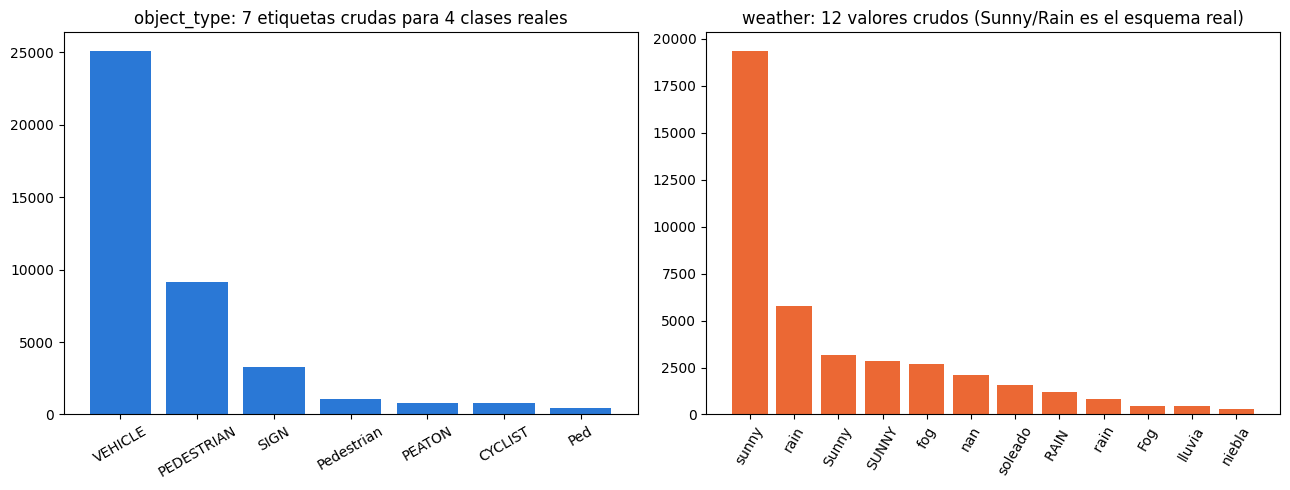

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

order_ot = df["object_type"].value_counts().index
axes[0].bar(order_ot, df["object_type"].value_counts()[order_ot], color="#2a78d6")
axes[0].set_title("object_type: 7 etiquetas crudas para 4 clases reales")
axes[0].tick_params(axis="x", rotation=30)

order_w = df["weather"].value_counts(dropna=False).index.astype(str)
axes[1].bar(order_w, df["weather"].value_counts(dropna=False).values, color="#eb6834")
axes[1].set_title("weather: 12 valores crudos (Sunny/Rain es el esquema real)")
axes[1].tick_params(axis="x", rotation=60)

fig.tight_layout()
plt.show()

### Hallazgos

- `object_type` tiene 7 etiquetas crudas para lo que deberían ser 4 clases:
  `VEHICLE` (25.111), `PEDESTRIAN` (9.134), `SIGN` (3.303), `Pedestrian`
  (1.069), `PEATON` (811), `CYCLIST` (789) y `Ped` (463). Las variantes de
  mayúscula y el español (`PEATON`) suman 2.343 filas que corresponden a la
  misma clase que `PEDESTRIAN`.
- `weather` tiene 12 valores distintos contando el nulo. Según el diccionario
  de datos, el Waymo real solo certifica `Sunny` y `Rain`. Encontramos
  variantes de mayúscula (`Sunny`, `SUNNY`, 3.179 y 2.821 filas), en español
  (`soleado` 1.567, `lluvia` 453), con espacio inicial (`" rain"`, 836 filas)
  y una categoría `fog`/`Fog`/`niebla` que no existe en el esquema real
  (2.664 + 476 + 288 = 3.428 filas, 8,4% del total).
- `weather` tiene 2.075 nulos explícitos (5,1%).
- `time_of_day` tiene 3 categorías consistentes y sin variantes: `Day`
  (28.494), `Night` (8.139), `Dawn/Dusk` (4.047). A nivel de etiquetas es
  consistente. Su coherencia estructural por segmento se revisa en la
  verificación 2.1.
- `detection_difficulty` tiene 2 niveles consistentes: `LEVEL_1` (36.165) y
  `LEVEL_2` (4.515, 11,1% del total).
- `sensor_version` tiene un solo valor en las 40.680 filas (`v2.0.1`). No
  aporta varianza.

In [10]:
# Verificacion 2.1: en el esquema real, weather y time_of_day describen el
# segmento completo (componente stats), no la deteccion individual. Por lo
# tanto deberian ser constantes dentro de cada segment_id.
for col in ["weather", "time_of_day"]:
    n = df.groupby("segment_id")[col].nunique(dropna=True)
    print(f"{col}: {(n > 1).sum()} de {df['segment_id'].nunique()} segmentos "
          f"tienen mas de un valor")

print()
ejemplo = df["segment_id"].iloc[0]
print(f"Ejemplo, segmento {ejemplo}, valores de weather dentro del mismo segmento:")
print(df.loc[df["segment_id"] == ejemplo, "weather"].value_counts(dropna=False))
print()
print(f"Ejemplo, segmento {ejemplo}, valores de time_of_day dentro del mismo segmento:")
print(df.loc[df["segment_id"] == ejemplo, "time_of_day"].value_counts(dropna=False))

weather: 153 de 153 segmentos tienen mas de un valor
time_of_day: 153 de 153 segmentos tienen mas de un valor

Ejemplo, segmento seg_0063, valores de weather dentro del mismo segmento:
weather
sunny      148
rain        32
Sunny       25
SUNNY       22
fog         15
NaN         11
RAIN         7
soleado      7
 rain        6
lluvia       3
Fog          3
niebla       2
Name: count, dtype: int64

Ejemplo, segmento seg_0063, valores de time_of_day dentro del mismo segmento:
time_of_day
Day          201
Night         58
Dawn/Dusk     22
Name: count, dtype: int64


### Hallazgos (verificación adicional)

- Los 153 segmentos (100%) tienen más de un valor de `weather` dentro del
  mismo `segment_id`, y los 153 (100%) también tienen más de un valor de
  `time_of_day`. En el ejemplo revisado, un mismo segmento de 20 segundos
  mezcla `sunny`, `rain`, `fog` y variantes de mayúscula/español, además de
  `Day`, `Night` y `Dawn/Dusk` al mismo tiempo.
- Esto contradice el esquema real: si `weather` y `time_of_day` vienen del
  componente `stats` del segmento completo, un mismo recorrido de 20 segundos
  no puede pasar de día a noche ni de sol a lluvia dentro de sí mismo. Es un
  defecto estructural nuevo, no explicado por errores de tipeo, y afecta al
  100% de los segmentos. Lo agregamos a la tabla de decisiones de la sección 7.

## 3. Nulos

In [11]:
nulos_explicitos = df.isnull().sum()
print("Nulos explicitos (NaN) por columna:")
print(nulos_explicitos[nulos_explicitos > 0])

Nulos explicitos (NaN) por columna:
speed_mps     787
weather      2075
dtype: int64


In [12]:
# Buscamos tokens de nulo oculto en todas las columnas de texto: vacio, espacio,
# "N/A", "desconocido" y variantes de mayuscula/minuscula.
tokens_ocultos = ["", " ", "n/a", "na", "desconocido", "unknown", "nd"]
for c in df.select_dtypes(include="object").columns:
    valores = df[c].astype(str).str.strip().str.lower()
    encontrados = valores.isin(tokens_ocultos)
    if encontrados.sum() > 0:
        print(f"{c}: {encontrados.sum()} filas con token oculto -> "
              f"{df.loc[encontrados, c].unique()[:5]}")

# timestamp_micros usa 'N/D' (no esta en la lista de tokens genericos, hay que
# revisarla aparte porque no es un patron estandar de nulo)
nd_timestamp = (df["timestamp_micros"].astype(str).str.strip() == "N/D").sum()
print(f"\ntimestamp_micros con 'N/D': {nd_timestamp}")

# -999 es el centinela clasico de nulo oculto en columnas numericas, lo buscamos
# explicitamente y no aparece
import numpy as np
for c in df.select_dtypes(include=np.number).columns:
    cnt = (df[c] == -999).sum()
    if cnt:
        print(f"{c}: {cnt} filas con -999")
print("Ninguna columna numerica usa -999 como centinela.")

# pero num_lidar_points no puede ser negativo y tiene un valor repetido: -1
print(f"\nnum_lidar_points == -1: {(df['num_lidar_points'] == -1).sum()} filas")


timestamp_micros con 'N/D': 60
Ninguna columna numerica usa -999 como centinela.

num_lidar_points == -1: 1198 filas


In [13]:
ts_oculto = df["timestamp_micros"].astype(str).str.strip() == "N/D"
lidar_centinela = df["num_lidar_points"] == -1
weather_nulo = df["weather"].isna()
speed_nulo = df["speed_mps"].isna()

algun_nulo = ts_oculto | lidar_centinela | weather_nulo | speed_nulo
print(f"Filas con algun nulo (explicito u oculto): {algun_nulo.sum():,} "
      f"({algun_nulo.mean():.2%} del total)")

Filas con algun nulo (explicito u oculto): 4,008 (9.85% del total)


### Hallazgos

- Nulos explícitos: 787 en `speed_mps` (1,93%) y 2.075 en `weather` (5,10%).
  El resto de las columnas no tiene nulos explícitos.
- Nulo oculto como texto: 60 filas en `timestamp_micros` con el valor `"N/D"`
  (0,15%). Pandas no lo reconoce como nulo porque es un string válido, la
  columna completa queda tipada como texto por esta razón.
- Nulo oculto como número centinela: 1.198 filas en `num_lidar_points` con el
  valor -1 (2,94%). Buscamos el centinela clásico -999 en todas las columnas
  numéricas y no aparece en ninguna. El centinela real es -1, mismo patrón,
  distinto valor: un conteo de puntos LiDAR no puede ser negativo.
- No encontramos strings vacíos, espacios en blanco, `"N/A"` ni
  `"desconocido"` en ninguna columna de texto.
- En total, 4.008 filas (9,85% del dataset) tienen al menos un nulo explícito
  u oculto en `weather`, `speed_mps`, `timestamp_micros` o `num_lidar_points`.

In [14]:
# Verificacion 2.2: si weather fuera un atributo constante del segmento, sus
# nulos deberian venir en bloque (segmentos completos sin dato). Revisamos si
# se concentran o estan dispersos.
seg_con_nulo = df[df["weather"].isna()]["segment_id"].nunique()
total_seg = df["segment_id"].nunique()
print(f"Segmentos afectados por al menos un nulo de weather: {seg_con_nulo} de {total_seg}")
print()
print("Filas nulas de weather por segmento (de los segmentos afectados):")
print(df[df["weather"].isna()].groupby("segment_id").size().describe())
print()

por_seg = df.groupby("segment_id").agg(total=("weather", "size"),
                                        nulos=("weather", lambda s: s.isna().sum()))
por_seg = por_seg[por_seg["nulos"] > 0]
por_seg["pct_nulo"] = por_seg["nulos"] / por_seg["total"]
print("Porcentaje de filas nulas dentro de cada segmento afectado:")
print(por_seg["pct_nulo"].describe())
print(f"\nSegmentos con 100% de sus filas nulas: {(por_seg['pct_nulo'] == 1).sum()}")
print(f"Segmentos con nulos mezclados (menos del 100%): {(por_seg['pct_nulo'] < 1).sum()}")

Segmentos afectados por al menos un nulo de weather: 153 de 153

Filas nulas de weather por segmento (de los segmentos afectados):
count    153.000000
mean      13.562092
std        3.697136
min        6.000000
25%       11.000000
50%       13.000000
75%       15.000000
max       31.000000
dtype: float64

Porcentaje de filas nulas dentro de cada segmento afectado:
count    153.000000
mean       0.050962
std        0.013171
min        0.022059
25%        0.042308
50%        0.050725
75%        0.057762
max        0.109155
Name: pct_nulo, dtype: float64

Segmentos con 100% de sus filas nulas: 0
Segmentos con nulos mezclados (menos del 100%): 153


### Hallazgos (verificación adicional)

- Los 153 segmentos (100%) tienen al menos un nulo de `weather`. Ningún
  segmento concentra el 100% de sus filas en nulo: el porcentaje de nulo por
  segmento va de 2,2% a 10,9%, con una media de 5,1% y una desviación de solo
  1,3 puntos porcentuales.
- Este patrón no calza con MNAR por segmento: si un tramo completo se hubiera
  quedado sin sensor de clima, esperaríamos algunos segmentos en 0% de nulos y
  otros en 100%. En cambio, la proporción es pareja en los 153 segmentos, lo
  que es compatible con una pérdida aleatoria fila a fila, no con una causa
  sistemática ligada al segmento.
- Esto no cambia la decisión de la sección 7: seguimos dejando `weather` como
  nulo en vez de imputarlo, porque el patrón disperso tampoco entrega una
  regla clara para inferir el valor faltante. Ahora la decisión queda
  respaldada por evidencia y no solo por prudencia.

## 4. Duplicados

In [15]:
dup_exactos = df.duplicated()
print(f"Filas exactamente duplicadas (las 16 columnas iguales): "
      f"{dup_exactos.sum():,} ({dup_exactos.mean():.2%})")

subset_logico = ["segment_id", "timestamp_micros", "id_interno"]
dup_logico = df.duplicated(subset=subset_logico)
print(f"Filas duplicadas por {subset_logico}: "
      f"{dup_logico.sum():,} ({dup_logico.mean():.2%})")

Filas exactamente duplicadas (las 16 columnas iguales): 480 (1.18%)
Filas duplicadas por ['segment_id', 'timestamp_micros', 'id_interno']: 680 (1.67%)


In [16]:
# Un mismo id_interno puede repetirse sin que la fila sea identica: revisamos
# un ejemplo donde el identificador coincide pero las lecturas del sensor no.
dup_logico_todos = df.duplicated(subset=subset_logico, keep=False)
dup_exacto_todos = df.duplicated(keep=False)
solo_logico = dup_logico_todos & ~dup_exacto_todos
print(f"Filas con mismo segment_id+timestamp_micros+id_interno pero valores "
      f"distintos en el resto de las columnas: {solo_logico.sum()}")

ejemplo_id = df.loc[solo_logico, "id_interno"].iloc[0]
df[df["id_interno"] == ejemplo_id]

Filas con mismo segment_id+timestamp_micros+id_interno pero valores distintos en el resto de las columnas: 400


,segment_id,timestamp_micros,id_interno,object_type,box_center_x,box_center_y,box_center_z,box_length,box_width,box_height,speed_mps,num_lidar_points,weather,time_of_day,detection_difficulty,sensor_version
338,seg_0111,1693775010400000,det_0028842,PEDESTRIAN,27.868,-1.755,1.094,0.943,0.806,1.765,1.141,90,sunny,Night,LEVEL_1,v2.0.1
1446,seg_0111,1693775010400000,det_0028842,PEDESTRIAN,27.711,-1.755,1.094,0.943,0.806,1.765,1.141,98,sunny,Night,LEVEL_1,v2.0.1


### Hallazgos

- 480 filas son exactamente duplicadas: las 16 columnas coinciden (1,18% del
  total).
- 680 filas quedan marcadas como duplicadas al usar `segment_id`,
  `timestamp_micros` e `id_interno` como criterio lógico (1,67% del total).
  Ese 680 incluye a las 480 exactas más 200 pares adicionales (400 filas)
  donde el identificador y el instante coinciden pero alguna lectura de
  sensor difiere (en el ejemplo revisado, `box_center_x` cambia de 27,868 a
  27,711 y `num_lidar_points` de 90 a 98 entre las dos filas).
- Que el identificador de una detección se repita dentro del mismo segmento y
  el mismo instante no es un caso válido: es un registro duplicado, con o sin
  ruido de sensor encima. El criterio lógico (`segment_id`, `timestamp_micros`,
  `id_interno`) cubre a las 480 exactas y a las 200 adicionales en un solo
  paso de limpieza.

## 5. Distribuciones y outliers

Trabajamos sobre `df_exp = df.copy()`, una copia explícita del DataFrame
crudo. La columna `object_type_clean` que usamos para agrupar los gráficos se
crea sobre esa copia, no sobre `df`, para que esta sección se pueda ejecutar
de forma independiente sin alterar el DataFrame original cargado del catálogo.
La normalización formal de `object_type` para el pipeline se hace recién en la
sección 8.

In [17]:
df_exp = df.copy()

OBJECT_TYPE_MAP = {"PED": "PEDESTRIAN", "PEATON": "PEDESTRIAN"}
df_exp["object_type_clean"] = df_exp["object_type"].str.strip().str.upper().replace(OBJECT_TYPE_MAP)

CAT = {"VEHICLE": "#2a78d6", "PEDESTRIAN": "#eb6834", "CYCLIST": "#1baf7a", "SIGN": "#eda100"}
ORDEN_TIPOS = ["SIGN", "PEDESTRIAN", "CYCLIST", "VEHICLE"]

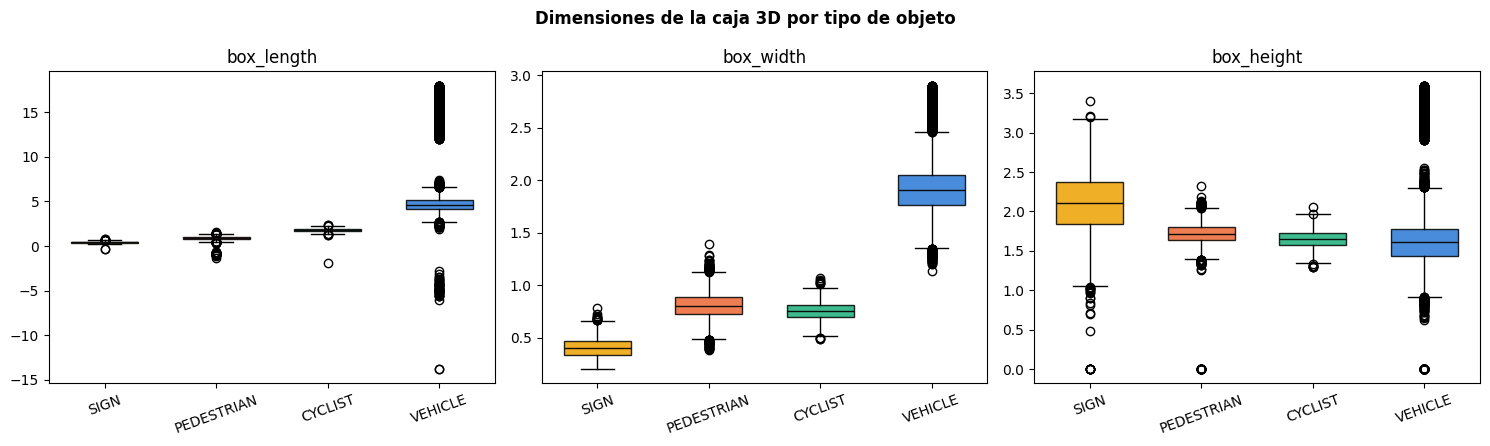

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col in zip(axes, ["box_length", "box_width", "box_height"]):
    datos = [df_exp.loc[df_exp["object_type_clean"] == t, col].dropna() for t in ORDEN_TIPOS]
    bp = ax.boxplot(datos, patch_artist=True, widths=0.6, medianprops={"color": "#0b0b0b"})
    for patch, t in zip(bp["boxes"], ORDEN_TIPOS):
        patch.set_facecolor(CAT[t])
        patch.set_alpha(0.85)
    ax.set_xticks(range(1, len(ORDEN_TIPOS) + 1))
    ax.set_xticklabels(ORDEN_TIPOS, rotation=20)
    ax.set_title(col)

fig.suptitle("Dimensiones de la caja 3D por tipo de objeto", fontweight="bold")
fig.tight_layout()
plt.show()

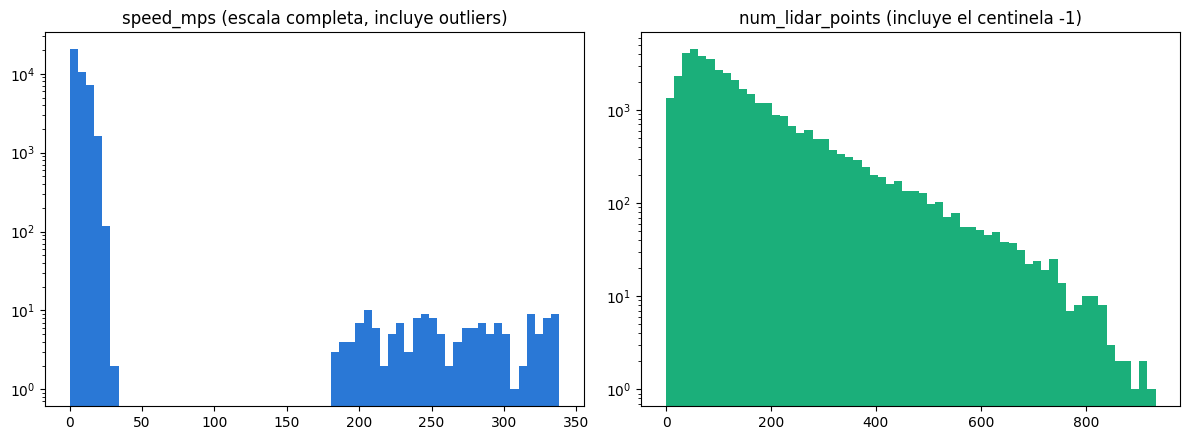

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(df_exp["speed_mps"].dropna(), bins=60, color="#2a78d6")
axes[0].set_title("speed_mps (escala completa, incluye outliers)")
axes[0].set_yscale("log")

axes[1].hist(df_exp["num_lidar_points"], bins=60, color="#1baf7a")
axes[1].set_title("num_lidar_points (incluye el centinela -1)")
axes[1].set_yscale("log")

fig.tight_layout()
plt.show()

In [20]:
# box_length negativo: no es un outlier estadistico, es un valor imposible
neg_len = df_exp["box_length"] < 0
print(f"box_length negativo: {neg_len.sum()} filas, minimo {df_exp['box_length'].min():.2f}")
print(df_exp.loc[neg_len, "object_type_clean"].value_counts())

box_length negativo: 80 filas, minimo -13.78
object_type_clean
VEHICLE       52
PEDESTRIAN    25
SIGN           2
CYCLIST        1
Name: count, dtype: int64


In [21]:
# box_height: buscamos el limite superior imposible sugerido (6 m) antes de fijarlo
print(df_exp["box_height"].describe(percentiles=[.5, .9, .99, .999]))
print(f"\nbox_height > 6: {(df_exp['box_height'] > 6).sum()} filas")
print(f"box_height maximo real observado: {df_exp['box_height'].max():.3f} m")

count    40680.000000
mean         1.695893
std          0.347135
min          0.000000
50%          1.676000
90%          2.003000
99%          3.140210
99.9%        3.555000
max          3.598000
Name: box_height, dtype: float64

box_height > 6: 0 filas
box_height maximo real observado: 3.598 m


In [22]:
# box_height en cero: el describe de la seccion 1 mostro un minimo de 0.000,
# lo revisamos en detalle antes de decidir que hacer
print(f"box_height == 0: {(df_exp['box_height'] == 0).sum()} filas")
print(df_exp[df_exp["box_height"] == 0]["object_type_clean"].value_counts())
print(df_exp[df_exp["box_height"] == 0][["box_length", "box_width", "num_lidar_points"]].describe())
print(f"box_width <= 0: {(df_exp['box_width'] <= 0).sum()} filas")

box_height == 0: 122 filas
object_type_clean
VEHICLE       77
PEDESTRIAN    36
SIGN           9
Name: count, dtype: int64
       box_length   box_width  num_lidar_points
count  122.000000  122.000000        122.000000
mean     3.281287    1.459557        122.688525
std      2.158935    0.585981        118.654376
min      0.200000    0.292000         -1.000000
25%      0.961500    0.846750         48.000000
50%      4.086500    1.685000         89.500000
75%      4.853750    1.957250        145.500000
max     14.029000    2.412000        725.000000
box_width <= 0: 0 filas


In [23]:
# box_length grande: IQR por tipo, contrastado con el detalle real de esas filas
for t, g in df_exp.groupby("object_type_clean"):
    q1, q3 = g["box_length"].quantile([.25, .75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((g["box_length"] < lo) | (g["box_length"] > hi)).sum()
    print(f"{t}: rango IQR normal [{lo:.2f}, {hi:.2f}] m, "
          f"{n_out} filas fuera de ese rango ({n_out / len(g):.1%})")

print()
grandes = df_exp[df_exp["box_length"] > 10]
print(f"box_length > 10 m: {len(grandes)} filas, todas de tipo "
      f"{grandes['object_type_clean'].unique()}")
print(grandes[["box_length", "box_width", "box_height"]].describe().loc[["mean", "min", "max"]])

CYCLIST: rango IQR normal [1.33, 2.27] m, 9 filas fuera de ese rango (1.1%)
PEDESTRIAN: rango IQR normal [0.50, 1.30] m, 95 filas fuera de ese rango (0.8%)
SIGN: rango IQR normal [0.14, 0.67] m, 14 filas fuera de ese rango (0.4%)
VEHICLE: rango IQR normal [2.66, 6.59] m, 804 filas fuera de ese rango (3.2%)

box_length > 10 m: 608 filas, todas de tipo ['VEHICLE']
      box_length  box_width  box_height
mean   15.144321   2.648947    3.265086
min    12.013000   2.401000    0.000000
max    17.998000   2.900000    3.598000


In [24]:
# speed_mps: localizamos el quiebre entre velocidad real e imposible
cola = df_exp["speed_mps"].dropna().sort_values()
cola = cola[cola > 25]
print("Valores de speed_mps por encima de 25 m/s, ordenados:")
print(cola.head(25).values)
print("...")
print(f"\nFilas con speed_mps > 50: {(df_exp['speed_mps'] > 50).sum()} "
      f"({(df_exp['speed_mps'] > 50).mean():.2%} del total)")

Valores de speed_mps por encima de 25 m/s, ordenados:
[ 25.055  25.121  25.139  25.178  25.2    25.503  25.511  25.756  25.772
  26.116  26.338  26.375  26.48   26.509  26.87   27.042  27.206  27.277
  27.633  27.745  28.049  29.395  32.425 182.764 183.038]
...

Filas con speed_mps > 50: 157 (0.39% del total)


### Hallazgos

- `box_length` tiene 80 filas negativas (mínimo -13,78 m), repartidas
  principalmente en `VEHICLE` (52) y `PEDESTRIAN`/variantes (25). Una
  longitud no puede ser negativa: es un valor imposible, no un caso límite a
  discutir.
- `box_height` no supera nunca los 6 m: el máximo real es 3,60 m. El umbral
  de 6 m que se suele usar como límite de seguridad no elimina ninguna fila
  hoy, pero lo dejamos como filtro preventivo para datos futuros.
- `box_height` sí tiene 122 filas en cero (0,30% del total), repartidas en
  `VEHICLE` (77), `PEDESTRIAN` (36) y `SIGN` (9), sin ninguna en `CYCLIST`.
  En esas mismas filas, `box_length` y `box_width` toman valores normales
  (mínimo 0,20 m y 0,29 m respectivamente, ninguno en cero), así que el
  problema es específico de la altura, no una fila completa en blanco. Una
  caja con altura cero es físicamente imposible, mismo criterio que
  `box_length` negativo. `box_width` no repite el problema: 0 filas con
  valor menor o igual a cero.
- El criterio IQR marca 804 filas de `VEHICLE` como atípicas en `box_length`
  (3,2% de esa clase). Al revisar el detalle, 608 de esas filas corresponden
  a vehículos de más de 10 m de largo, con ancho promedio 2,65 m y alto
  promedio 3,27 m, dimensiones consistentes con buses o camiones
  articulados. No son un error de medición, son una clase de vehículo más
  grande dentro de la misma categoría `VEHICLE`. Eliminarlas por regla IQR
  borraría a los buses del dataset completo.
- `speed_mps` tiene un quiebre claro en su distribución: los valores reales
  llegan hasta 32,4 m/s y el siguiente valor registrado salta a 182,8 m/s,
  sin nada en el medio. 157 filas (0,39% del total) superan los 50 m/s, todas
  caen dentro de ese quiebre vacío. Ningún vehículo, peatón, ciclista o
  señalética alcanza 180 m/s: es un error de sensor.
- `num_lidar_points` repite el centinela -1 visto en la sección 3 (1.198
  filas). En el histograma en escala logarítmica se ve como una barra aislada
  en el extremo negativo, separada del resto de la distribución.

In [25]:
# Cierre del TODO de box_center_z: evidencia antes de decidir
neg_z = df_exp[df_exp["box_center_z"] < 0]
print("box_center_z negativo por tipo de objeto:")
print(neg_z["object_type_clean"].value_counts())
print()

conteo_tipo = df_exp["object_type_clean"].value_counts()
for t in neg_z["object_type_clean"].value_counts().index:
    n_neg = (neg_z["object_type_clean"] == t).sum()
    n_tot = conteo_tipo[t]
    print(f"{t}: {n_neg} de {n_tot} ({n_neg / n_tot:.2%})")

print()
print("box_height de las filas con z negativo, por tipo:")
print(neg_z.groupby("object_type_clean")["box_height"].mean().round(3))
print()
print("box_height general por tipo (para comparar):")
print(df_exp.groupby("object_type_clean")["box_height"].mean().round(3))

print()
corr_z_altura = df_exp["box_center_z"].corr(df_exp["box_height"] / 2)
print(f"Correlacion entre box_center_z y box_height/2 (todo el dataset): {corr_z_altura:.3f}")

box_center_z negativo por tipo de objeto:


object_type_clean
VEHICLE       275
PEDESTRIAN    146
SIGN           37
CYCLIST        10
Name: count, dtype: int64

VEHICLE: 275 de 25111 (1.10%)
PEDESTRIAN: 146 de 11477 (1.27%)
SIGN: 37 de 3303 (1.12%)
CYCLIST: 10 de 789 (1.27%)

box_height de las filas con z negativo, por tipo:
object_type_clean
CYCLIST       1.672
PEDESTRIAN    1.672
SIGN          2.019
VEHICLE       1.644
Name: box_height, dtype: float64

box_height general por tipo (para comparar):
object_type_clean
CYCLIST       1.650
PEDESTRIAN    1.714
SIGN          2.102
VEHICLE       1.636
Name: box_height, dtype: float64

Correlacion entre box_center_z y box_height/2 (todo el dataset): 0.005


### Cierre del TODO: box_center_z

- 468 filas tienen `box_center_z` negativo (mínimo -0,678 m), entre 1,10% y
  1,27% de cada tipo de objeto (`VEHICLE` 275, `PEDESTRIAN` 146, `SIGN` 37,
  `CYCLIST` 10). La proporción es prácticamente la misma en las 4 clases: no
  se concentra en ninguna.
- La altura (`box_height`) de esas filas es muy parecida al promedio general
  del mismo tipo (por ejemplo, `PEDESTRIAN` con z negativo promedia 1,672 m
  de altura contra 1,714 m en general). Si el objeto estuviera en una
  pendiente o rampa, esperaríamos alturas o formas distintas al resto de su
  categoría, y no es el caso.
- La correlación entre `box_center_z` y `box_height / 2` en todo el dataset
  (no solo las filas negativas) es 0,005, prácticamente nula. Si `z`
  representara el centro vertical real de un objeto apoyado en el suelo,
  debería moverse junto con la altura fila a fila. No lo hace, ni en las
  filas negativas ni en el resto: la hipótesis de la pendiente o rampa no
  tiene respaldo en los datos.
- Decisión: conservar las filas y documentar `box_center_z` como una
  limitación conocida del dataset sintético, no como un error que haya que
  filtrar. El valor no distorsiona `box_height`, `box_length` ni
  `box_width`, que son las variables que efectivamente usamos en el resto
  del análisis. Reemplazamos el TODO de la sección 7 por esta decisión.

## 6. Relaciones que deben conservarse

Correlacion distancia vs num_lidar_points (lineal): -0.77
Correlacion log(distancia) vs num_lidar_points: -0.95


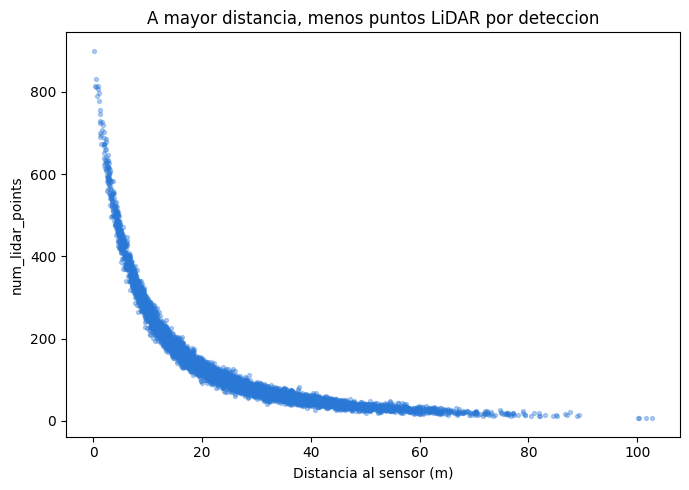

In [26]:
import numpy as np

df_exp["distancia_m"] = np.sqrt(df_exp["box_center_x"] ** 2 + df_exp["box_center_y"] ** 2)
validos = df_exp[df_exp["num_lidar_points"] >= 0]

corr_lineal = validos["distancia_m"].corr(validos["num_lidar_points"])
corr_log = np.log1p(validos["distancia_m"]).corr(validos["num_lidar_points"])
print(f"Correlacion distancia vs num_lidar_points (lineal): {corr_lineal:.2f}")
print(f"Correlacion log(distancia) vs num_lidar_points: {corr_log:.2f}")

fig, ax = plt.subplots(figsize=(7, 5))
muestra = validos.sample(6000, random_state=0)
ax.scatter(muestra["distancia_m"], muestra["num_lidar_points"], s=8, alpha=0.35, color="#2a78d6")
ax.set_xlabel("Distancia al sensor (m)")
ax.set_ylabel("num_lidar_points")
ax.set_title("A mayor distancia, menos puntos LiDAR por deteccion")
fig.tight_layout()
plt.show()

In [27]:
pocos_puntos = validos[validos["num_lidar_points"] < 20]
muchos_puntos = validos[validos["num_lidar_points"] >= 20]

print(f"Detecciones con menos de 20 puntos LiDAR: {len(pocos_puntos):,}, "
      f"{(pocos_puntos['detection_difficulty'] == 'LEVEL_2').mean():.1%} son LEVEL_2")
print(f"Detecciones con 20 o mas puntos LiDAR: {len(muchos_puntos):,}, "
      f"{(muchos_puntos['detection_difficulty'] == 'LEVEL_2').mean():.1%} son LEVEL_2")

Detecciones con menos de 20 puntos LiDAR: 533, 98.9% son LEVEL_2
Detecciones con 20 o mas puntos LiDAR: 38,949, 9.9% son LEVEL_2


In [28]:
print("Dimensiones medianas por tipo de objeto (largo, ancho, alto en metros):")
print(df_exp.groupby("object_type_clean")[["box_length", "box_width", "box_height"]].median().round(2))

Dimensiones medianas por tipo de objeto (largo, ancho, alto en metros):
                   box_length  box_width  box_height
object_type_clean                                   
CYCLIST                  1.81       0.75        1.65
PEDESTRIAN               0.90       0.80        1.72
SIGN                     0.40       0.40        2.10
VEHICLE                  4.61       1.90        1.61


In [29]:
speed_sign = df_exp.loc[df_exp["object_type_clean"] == "SIGN", "speed_mps"]
print(speed_sign.describe())
n_validas = speed_sign.notna().sum()
n_sobre_1 = (speed_sign > 1).sum()
print(f"\nSenaletica con speed_mps > 1: {n_sobre_1} de {n_validas} "
      f"({n_sobre_1 / n_validas:.2%})")

count    3243.000000
mean        0.793176
std        14.446023
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       332.298000
Name: speed_mps, dtype: float64

Senaletica con speed_mps > 1: 10 de 3243 (0.31%)


### Hallazgos

- La distancia al sensor y `num_lidar_points` están correlacionadas
  negativamente: -0,77 en escala lineal y -0,95 usando el logaritmo de la
  distancia. Tiene sentido físico: el mismo objeto refleja menos rayos LiDAR
  mientras más lejos está. No es un defecto, es la física del sensor.
- La cantidad de puntos LiDAR predice la dificultad de la detección. De las
  detecciones con menos de 20 puntos, 98,9% quedan marcadas `LEVEL_2`. De las
  que tienen 20 puntos o más, solo 9,9% son `LEVEL_2`. Es una relación fuerte
  y coherente con el resto del dataset, hay que conservarla.
- Las dimensiones medianas por tipo son consistentes con el mundo real:
  `PEDESTRIAN` tiene una altura mediana de 1,72 m, cercana a la estatura
  promedio de una persona adulta. `VEHICLE` tiene un ancho mediano de 1,90 m
  y un largo de 4,61 m, coherente con un auto o camioneta.
- La señalética (`SIGN`) tiene velocidad mediana 0,0 m/s y percentil 75
  también 0,0 m/s, como corresponde a un objeto fijo. Solo 10 de 3.243 filas
  de `SIGN` (0,31%) superan 1 m/s, y esas mismas filas coinciden con las
  velocidades imposibles marcadas en la sección 5.

## 7. Tabla de decisiones

| Columna | Problema detectado | Acción | Justificación |
|---|---|---|---|
| `object_type` | 7 etiquetas para 4 clases reales (`Ped`, `Pedestrian`, `PEATON` son la misma clase que `PEDESTRIAN`) | Normalizar a mayúscula y mapear las 3 variantes a `PEDESTRIAN` | Es la misma clase escrita de 3 formas distintas, unificarla no pierde información. |
| `weather` | 12 valores para un esquema real de 2 (`Sunny`, `Rain`); incluye `fog`/`niebla` (3.428 filas, 8,4%) que no existe en el dataset real | Normalizar mayúscula y espacios, mapear `soleado`/`lluvia` a `sunny`/`rain`, mantener `fog` como categoría aparte marcada como no verificada | El diccionario de datos de la fuente confirma que el `weather` real de Waymo v2 solo toma los valores `Sunny` y `Rain`, y que `fog` junto con las variantes en español se agregaron deliberadamente para ejercitar la limpieza de categorías. No es una suposición nuestra: `fog` es un defecto inyectado confirmado por la documentación de origen, no una condición climática real. Por eso no se fuerza a `sunny` ni a `rain`, se documenta como categoría no verificada. |
| `weather` | 2.075 nulos explícitos (5,1%), dispersos de forma pareja en el 100% de los segmentos (entre 2,2% y 10,9% por segmento) | Dejar como nulo | El patrón disperso no calza con una causa sistemática por segmento (MNAR) y tampoco entrega una regla clara para inferir el valor. Imputar un clima inventaría una medición que el sensor no hizo. |
| `speed_mps` | 787 nulos explícitos (1,93%) | Dejar como nulo | Mismo criterio que `weather`: no hay base para inventar una velocidad. |
| `speed_mps` | 157 filas con velocidad imposible, salto vacío entre 32,4 y 182,8 m/s (0,39%) | Convertir a nulo | Ningún vehículo, peatón, ciclista o señal alcanza 180 m/s, es error de sensor. |
| `box_length` | 80 filas negativas, mínimo -13,78 (0,20%) | Eliminar la fila | Una longitud negativa no es un valor discutible, es un error de captura. |
| `box_length` | 608 filas sobre 10 m, todas `VEHICLE`, con ancho y alto coherentes | Conservar | Son vehículos reales (buses o camiones). El criterio IQR las marca como atípicas, pero eliminarlas borra una categoría completa del dataset. |
| `box_height` | 122 filas en cero (0,30%), en `VEHICLE` (77), `PEDESTRIAN` (36) y `SIGN` (9); `box_length` y `box_width` de esas mismas filas son normales | Eliminar la fila | Una altura de 0 m es físicamente imposible para un objeto real, mismo criterio que `box_length` negativo. `box_width` no repite el problema (0 filas menores o iguales a cero), no hace falta un filtro adicional para esa columna. |
| `num_lidar_points` | 1.198 filas con valor -1 (2,94%) | Convertir a nulo | Un conteo de puntos no puede ser negativo, -1 es un centinela de dato faltante. |
| `timestamp_micros` | 60 filas con texto `"N/D"` en vez de número (0,15%) | Convertir a nulo y castear la columna a numérico | El valor no es un timestamp válido. Forzar el tipo numérico habilita operaciones de tiempo en el resto de las filas. |
| filas completas | 680 filas duplicadas por `segment_id` + `timestamp_micros` + `id_interno` (1,67%), incluye 480 duplicados exactos | Eliminar duplicados por ese criterio, dejando la primera aparición | El identificador de una detección no debería repetirse dentro del mismo instante y segmento. Conservar solo una copia evita inflar los conteos. |
| `sensor_version` | Un solo valor en las 40.680 filas | Eliminar la columna | No aporta varianza ni información para ningún análisis o modelo. Según el diccionario de datos del docente, esta columna no existe en el esquema real de Waymo v2: se agregó al dataset sintético a propósito, para ilustrar una variable de varianza cero. |
| `weather` / `time_of_day` | Varían dentro de un mismo `segment_id`: el 100% de los 153 segmentos tiene más de un valor de `weather` y más de un valor de `time_of_day`, cuando en el esquema real ambos deberían ser constantes por segmento | Documentar como limitación estructural; tratar ambas columnas como un atributo de la fila individual, no del segmento completo; si en el futuro se necesita un valor por segmento, usar la moda y dejar registrado que es una aproximación | El defecto afecta al 100% de los segmentos, no es un caso aislado. Inventar un único valor por segmento reemplazaría datos existentes por un supuesto no verificable. En el Waymo Open Dataset v2 real, `weather` y `time_of_day` provienen del componente `stats`, que es una tabla a nivel de segmento completo, no de la detección individual: por diseño no pueden variar dentro de un mismo segmento. Dejamos registrada la predicción de que en los datos reales ambas columnas serán constantes por segmento, para contrastarla cuando se incorporen. |
| `box_center_z` | 468 filas negativas (1,15% del total), mínimo -0,678 | Conservar y documentar como limitación conocida | La proporción es pareja entre los 4 tipos de objeto (1,10% a 1,27%), la altura de esas filas no difiere del promedio de su tipo, y la correlación entre `box_center_z` y `box_height/2` en todo el dataset es prácticamente nula (0,005). No hay evidencia de pendiente o rampa ni de otro mecanismo físico. No distorsiona las variables que usamos en el resto del análisis. |

## 8. Limpieza

Implementamos cada decisión de la sección 7 como una función pura: recibe un
DataFrame, devuelve uno nuevo y no modifica el de entrada. Todas parten con
`df = df.copy()`.

In [30]:
import pandas as pd
import numpy as np


def convertir_nulos_ocultos(df: pd.DataFrame) -> pd.DataFrame:
    """
    Convierte a NaN explicito los dos nulos ocultos de la seccion 3.

    timestamp_micros: el texto "N/D" (60 filas, 0,15%) pasa a NaN y la
    columna queda casteada a numerico.
    num_lidar_points: el centinela -1 (1.198 filas, 2,94%) pasa a NaN.
    """
    df = df.copy()
    df["timestamp_micros"] = df["timestamp_micros"].replace("N/D", np.nan)
    df["timestamp_micros"] = pd.to_numeric(df["timestamp_micros"], errors="coerce")
    df["num_lidar_points"] = df["num_lidar_points"].replace(-1, np.nan)
    return df

In [31]:
def normalizar_categorias(df: pd.DataFrame) -> pd.DataFrame:
    """
    Normaliza las etiquetas inconsistentes de object_type y weather.

    object_type: 2.343 filas con variantes de mayuscula o en espanol (Ped,
    Pedestrian, PEATON) se unifican en PEDESTRIAN.
    weather: 10.806 filas con variantes de mayuscula, espacio inicial o en
    espanol (Sunny, SUNNY, soleado, RAIN, " rain", lluvia, Fog, niebla) se
    normalizan a minuscula sin espacios. fog se mantiene como categoria
    propia: no se fuerza a sunny ni a rain (ver seccion 7).
    """
    df = df.copy()
    object_type_map = {"PED": "PEDESTRIAN", "PEATON": "PEDESTRIAN"}
    df["object_type"] = df["object_type"].str.strip().str.upper().replace(object_type_map)

    weather_map = {"soleado": "sunny", "lluvia": "rain", "niebla": "fog"}
    df["weather"] = df["weather"].str.strip().str.lower().replace(weather_map)
    return df

In [32]:
def eliminar_columnas_sin_varianza(
    df: pd.DataFrame,
    columnas_protegidas: list[str] | None = None,
) -> pd.DataFrame:
    """
    Elimina columnas con un solo valor unico en todo el dataset.

    Generica: no asume que la columna se llama sensor_version, detecta
    cualquier columna sin varianza. En detecciones_crudas afecta a 1 columna
    (sensor_version, un unico valor v2.0.1 en las 40.680 filas).

    columnas_protegidas existe porque esta funcion se va a reutilizar sobre
    los datos reales de Waymo, donde weather puede venir 100% sunny para un
    segmento asoleado real, no por un defecto. Sin proteccion, la funcion
    borraria esa columna en silencio solo porque en ese subconjunto no varia.
    Pasamos ["weather", "time_of_day"] para que nunca se eliminen aunque su
    varianza caiga a 0 en algun corte de datos.
    """
    df = df.copy()
    protegidas = set(columnas_protegidas or [])
    sin_varianza = [
        c for c in df.columns
        if c not in protegidas and df[c].nunique(dropna=True) <= 1
    ]
    if sin_varianza:
        print(f"Columnas sin varianza eliminadas: {sin_varianza}")
    return df.drop(columns=sin_varianza)

In [33]:
def eliminar_duplicados_logicos(df: pd.DataFrame) -> pd.DataFrame:
    """
    Elimina las filas duplicadas segun el criterio logico de la seccion 4.

    subset=[segment_id, timestamp_micros, id_interno], keep="first". Afecta
    a 680 filas (480 duplicados exactos mas 200 pares con lecturas de sensor
    levemente distintas bajo el mismo identificador).
    """
    df = df.copy()
    subset = ["segment_id", "timestamp_micros", "id_interno"]
    return df.drop_duplicates(subset=subset, keep="first")

In [34]:
def filtrar_valores_imposibles(df: pd.DataFrame, altura_max: float, velocidad_max: float) -> pd.DataFrame:
    """
    Elimina dimensiones imposibles y marca velocidades imposibles.

    Elimina box_length <= 0 (80 filas) y box_height <= 0 (122 filas), sin
    superposicion entre ambos grupos. Elimina box_height > altura_max (0
    filas hoy, filtro preventivo). Convierte speed_mps > velocidad_max a NaN
    (157 filas), sin eliminar la fila: el resto de esas detecciones es
    valido.
    No aplica ningun filtro por IQR ni por desviacion estandar sobre
    box_length: las 608 filas de VEHICLE con box_length > 10 m son buses y
    camiones reales, con ancho y alto coherentes, y se conservan (ver
    seccion 5 y seccion 7).
    """
    df = df.copy()
    df = df[df["box_length"] > 0]
    df = df[df["box_height"] > 0]
    df = df[df["box_height"] <= altura_max]
    df = df.copy()
    df.loc[df["speed_mps"] > velocidad_max, "speed_mps"] = np.nan
    return df

In [35]:
def crear_variables_derivadas(df: pd.DataFrame) -> pd.DataFrame:
    """
    Agrega 3 variables derivadas, sin eliminar ni modificar columnas existentes.

    distancia_m: distancia euclidiana al sensor, la misma que usamos en la
    seccion 6 para explicar la caida de num_lidar_points con la distancia.
    volumen_caja: box_length x box_width x box_height.
    densidad_puntos: num_lidar_points / volumen_caja, puntos LiDAR por metro
    cubico de caja.

    Debe ejecutarse despues de filtrar_valores_imposibles: densidad_puntos
    divide por volumen_caja, y esa division solo es segura si ya se
    eliminaron las filas con box_height en cero (y por lo tanto
    volumen_caja en cero).
    """
    df = df.copy()
    df["distancia_m"] = np.sqrt(df["box_center_x"] ** 2 + df["box_center_y"] ** 2)
    df["volumen_caja"] = df["box_length"] * df["box_width"] * df["box_height"]
    df["densidad_puntos"] = df["num_lidar_points"] / df["volumen_caja"]
    return df

In [36]:
# altura_max=6.0 viene de la celda de la seccion 5 que revisa box_height con
# describe(percentiles=[.5,.9,.99,.999]) y el conteo "box_height > 6": el
# maximo real es 3,598 m, 6 m queda como techo preventivo sin efecto hoy.
# velocidad_max=50.0 viene de la celda de la seccion 5 que ordena la cola de
# speed_mps por encima de 25 m/s: el salto vacio entre 32,425 y 182,764 m/s
# justifica el corte en 50.
ALTURA_MAX = 6.0
VELOCIDAD_MAX = 50.0
COLUMNAS_PROTEGIDAS = ["weather", "time_of_day"]

pasos = [
    ("convertir_nulos_ocultos", convertir_nulos_ocultos),
    ("normalizar_categorias", normalizar_categorias),
    ("eliminar_columnas_sin_varianza", lambda d: eliminar_columnas_sin_varianza(d, COLUMNAS_PROTEGIDAS)),
    ("eliminar_duplicados_logicos", eliminar_duplicados_logicos),
    ("filtrar_valores_imposibles", lambda d: filtrar_valores_imposibles(d, ALTURA_MAX, VELOCIDAD_MAX)),
    ("crear_variables_derivadas", crear_variables_derivadas),
]

df_limpio = df.copy()
for nombre, funcion in pasos:
    antes = df_limpio.shape
    df_limpio = funcion(df_limpio)
    print(f"{nombre}: {antes} -> {df_limpio.shape}")

convertir_nulos_ocultos: (40680, 16) -> (40680, 16)
normalizar_categorias: (40680, 16) -> (40680, 16)
Columnas sin varianza eliminadas: ['sensor_version']
eliminar_columnas_sin_varianza: (40680, 16) -> (40680, 15)
eliminar_duplicados_logicos: (40680, 15) -> (40000, 15)


filtrar_valores_imposibles: (40000, 15) -> (39800, 15)
crear_variables_derivadas: (39800, 15) -> (39800, 18)


### Hallazgos

- El dataset queda en 39.800 filas de 40.680 (97,84%), y pasa de 16 a 18
  columnas: pierde `sensor_version` y gana `distancia_m`, `volumen_caja` y
  `densidad_puntos`.
- Se eliminaron 880 filas en total (2,16% del original): 680 por el criterio
  de duplicado lógico y 200 por dimensión imposible (`box_length` o
  `box_height` en cero o negativo, sin superposición entre ambos grupos; las
  202 filas originales menos 2 que ya se habían ido con los duplicados dan
  las 200 que se eliminan en este paso).
- Se convirtieron a NaN, sin eliminar la fila: 60 en `timestamp_micros`, 155
  en `speed_mps` (de las 157 originales, 2 se fueron con las filas
  eliminadas) y 1.175 en `num_lidar_points` (de las 1.198 originales, 23 se
  fueron con las filas eliminadas).
- No se aplicó ningún filtro de longitud sobre `box_length`: los buses y
  camiones se revisan en la sección 9.

## 9. Verificación antes/después

In [37]:
print("object_type en df_limpio:")
print(df_limpio["object_type"].value_counts(dropna=False))
print(f"\n{df_limpio['object_type'].nunique()} categorias (eran 7 en el crudo)")

print("\nweather en df_limpio:")
print(df_limpio["weather"].value_counts(dropna=False))
print(f"\n{df_limpio['weather'].dropna().nunique()} categorias sin contar el nulo (eran 11 en el crudo)")

object_type en df_limpio:
object_type
VEHICLE       24577
PEDESTRIAN    11222
SIGN           3225
CYCLIST         776
Name: count, dtype: int64

4 categorias (eran 7 en el crudo)

weather en df_limpio:
weather
sunny    26374
rain      8051
fog       3352
NaN       2023
Name: count, dtype: int64

3 categorias sin contar el nulo (eran 11 en el crudo)


In [38]:
nulos_crudo = df.isnull().sum()
nulos_limpio = df_limpio.isnull().sum()
print("Nulos por columna, crudo (solo explicitos):")
print(nulos_crudo[nulos_crudo > 0])
print("\nNulos por columna, limpio (explicitos + centinelas convertidos):")
print(nulos_limpio[nulos_limpio > 0])

Nulos por columna, crudo (solo explicitos):
speed_mps     787
weather      2075
dtype: int64

Nulos por columna, limpio (explicitos + centinelas convertidos):
timestamp_micros      60
speed_mps            921
num_lidar_points    1175
weather             2023
densidad_puntos     1175
dtype: int64


In [39]:
dup_logico_limpio = df_limpio.duplicated(subset=["segment_id", "timestamp_micros", "id_interno"]).sum()
print(f"Duplicados logicos en df_limpio: {dup_logico_limpio}")

print(f"\n'sensor_version' en df_limpio: {'sensor_version' in df_limpio.columns}")
print(f"tipo de timestamp_micros en df_limpio: {df_limpio['timestamp_micros'].dtype}")

Duplicados logicos en df_limpio: 0

'sensor_version' en df_limpio: False
tipo de timestamp_micros en df_limpio: float64


In [40]:
buses_crudo = (df["box_length"] > 10).sum()
buses_limpio = (df_limpio["box_length"] > 10).sum()
print(f"box_length > 10 m, crudo: {buses_crudo}")
print(f"box_length > 10 m, limpio: {buses_limpio}")
print(f"diferencia: {buses_crudo - buses_limpio} filas")

box_length > 10 m, crudo: 608
box_length > 10 m, limpio: 597
diferencia: 11 filas


| Métrica | Crudo | Limpio |
|---|---|---|
| Filas | 40.680 | 39.800 |
| Columnas | 16 | 18 |
| Categorías `object_type` | 7 | 4 |
| Categorías `weather` (sin nulo) | 11 | 3 |
| Duplicados lógicos | 680 | 0 |
| Nulos totales (suma de columnas) | 2.862 | 5.354 |
| Filas con `box_length` > 10 m | 608 | 597 |

In [41]:
validos_limpio = df_limpio[df_limpio["num_lidar_points"].notna()]
corr_lineal_limpio = validos_limpio["distancia_m"].corr(validos_limpio["num_lidar_points"])
corr_log_limpio = np.log1p(validos_limpio["distancia_m"]).corr(validos_limpio["num_lidar_points"])
print(f"Correlacion distancia vs num_lidar_points, limpio (lineal): {corr_lineal_limpio:.2f}")
print(f"Correlacion log(distancia) vs num_lidar_points, limpio: {corr_log_limpio:.2f}")
print("Comparar con el crudo (seccion 6): -0.77 lineal, -0.95 logaritmica")

Correlacion distancia vs num_lidar_points, limpio (lineal): -0.77
Correlacion log(distancia) vs num_lidar_points, limpio: -0.95
Comparar con el crudo (seccion 6): -0.77 lineal, -0.95 logaritmica


### Hallazgos

- `object_type` queda en 4 categorías (`VEHICLE` 24.577, `PEDESTRIAN` 11.222,
  `SIGN` 3.225, `CYCLIST` 776) y `weather` en 3 (`sunny` 26.374, `rain`
  8.051, `fog` 3.352), más 2.023 nulos. Los dos chequeos pasan.
- Los nulos totales suben de 2.862 en el crudo a 5.354 en el limpio. No es un
  retroceso: la mayor parte del aumento corresponde a los centinelas que la
  sección 3 encontró ocultos (`"N/D"` y `-1`) y que ahora quedan visibles
  como NaN explícito, más las 155 velocidades imposibles convertidas. No
  aparece ningún nulo nuevo fuera de esas columnas ya identificadas.
- Duplicados lógicos en el limpio: 0. El chequeo pasa.
- `sensor_version` ya no está entre las columnas. `timestamp_micros` quedó
  como `float64`. Ambos chequeos pasan.
- Los buses siguen presentes: 597 filas con `box_length` > 10 m contra 608
  en el crudo. La diferencia de 11 filas no tiene relación con ningún filtro
  de longitud: 10 se fueron por el criterio de duplicado lógico y 1 por
  tener `box_height` en cero. Ninguna se eliminó por ser un vehículo largo.
- La correlación entre `distancia_m` y `num_lidar_points` en el limpio da
  -0,77 lineal y -0,95 logarítmica, prácticamente idéntica a la del crudo
  (-0,77 y -0,95 en la sección 6). La relación física sobrevive intacta a la
  limpieza.

## 10. Conclusiones

**Defectos encontrados, por tipo:**

- Categorías inconsistentes: `object_type` con 7 etiquetas para 4 clases
  reales, `weather` con 12 valores para un esquema real de 2 (`Sunny`,
  `Rain`), más una tercera categoría (`fog`) no verificable contra ese
  esquema.
- Nulos ocultos: el texto `"N/D"` en `timestamp_micros` (60 filas) y el
  centinela -1 en `num_lidar_points` (1.198 filas), ninguno de los dos
  detectable con `isnull()` sin revisarlos primero.
- Valores imposibles: `box_length` negativo (80 filas), `box_height` en cero
  (122 filas) y velocidades sobre 180 m/s (157 filas), separadas de los
  buses reales (`box_length` > 10 m, 608 filas), que no son un error.
- Duplicados: 680 filas por el criterio lógico `segment_id` +
  `timestamp_micros` + `id_interno` (480 exactas más 200 con ruido de
  sensor).
- Problemas estructurales: `weather` y `time_of_day` varían dentro de un
  mismo segmento en el 100% de los 153 segmentos, cuando en el esquema real
  deberían ser constantes; `sensor_version` sin varianza, agregada a
  propósito según el diccionario de datos del docente.

**Qué se eliminó, qué se convirtió a nulo y qué se conservó:**

- Eliminado: 880 filas (2,16% del original, 680 por duplicado lógico y 200
  por dimensión imposible) y la columna `sensor_version`. El dataset limpio
  queda en 39.800 filas y 18 columnas.
- Convertido a nulo, sin eliminar la fila: 60 en `timestamp_micros`, 155 en
  `speed_mps` y 1.175 en `num_lidar_points`.
- Conservado a pesar de parecer atípico: 597 filas de `VEHICLE` con
  `box_length` > 10 m (buses y camiones reales) y 468 filas con
  `box_center_z` negativo, documentadas como limitación conocida.

**Relaciones que sobreviven a la limpieza:**

- La correlación entre `distancia_m` y `num_lidar_points` se mantiene en
  -0,77 lineal y -0,95 logarítmica, igual que en el crudo. Importa porque es
  evidencia de que, más allá de sus defectos de forma, el dataset conserva
  un comportamiento físico consistente con un sensor LiDAR real, que es lo
  que se necesita para evaluar un modelo de detección con sentido.
- Las filas de `box_length` > 10 m, `box_height` en cero y `speed_mps`
  imposible no se solapan entre sí de forma relevante, lo que confirma que
  cada filtro está corrigiendo un defecto distinto y no una misma fuente de
  ruido.

**Limitaciones conocidas que quedan sin resolver:**

- `box_center_z`: 468 filas negativas sin una causa física confirmada,
  documentadas, no corregidas.
- `weather` / `time_of_day`: inconsistencia estructural por segmento en el
  100% de los 153 segmentos, sin una forma confiable de derivar un valor
  único por segmento sin asumir una aproximación (la moda).
- `fog`: categoría no verificable contra el esquema real de Waymo, que solo
  certifica `Sunny` y `Rain`. Se mantiene separada, no se fuerza a ninguna
  de las dos.

**Desbalance de clases:**

`object_type` en el dataset limpio: `VEHICLE` 61,75% (24.577), `PEDESTRIAN`
28,20% (11.222), `SIGN` 8,10% (3.225) y `CYCLIST` 1,95% (776). Un modelo
evaluado sobre este dataset tal cual tiene casi 32 veces más evidencia de
`VEHICLE` que de `CYCLIST`. Una métrica agregada como accuracy global puede
esconder un desempeño mucho peor sobre la clase minoritaria. Cualquier
análisis de sesgos o de equidad del sistema de detección debe reportar
métricas por clase, no solo un promedio. `detection_difficulty` también está
desbalanceada: `LEVEL_2` es 11,1% del dataset original, así que los casos
difíciles pueden diluirse si se evalúa solo con el promedio general.

**Qué queda pendiente:**

- Llevar `convertir_nulos_ocultos`, `normalizar_categorias`,
  `eliminar_columnas_sin_varianza`, `eliminar_duplicados_logicos`,
  `filtrar_valores_imposibles` y `crear_variables_derivadas` a nodos de
  Kedro (`nodes.py`) y armar el pipeline (`pipeline.py`). No se creó ningún
  archivo de Kedro en este notebook.
- Incorporar los datos reales de Waymo Open Dataset v2 para contrastar la
  predicción registrada en la sección 7: que `weather` y `time_of_day` sean
  constantes por segmento en los datos reales.
- Revisar `box_center_z` con más evidencia cuando se disponga de contexto
  adicional del segmento, por ejemplo terreno o pendiente real.